# Weather Context Analysis

This notebook provides meteorological context for the event-window analysis
built in earlier Phase 4 notebooks. It places PM2.5 alongside wind speed,
temperature, and humidity on shared time axes, and separately summarizes how
each weather variable behaves in the Pre, Event, and Post periods of the +/-7
day GRAP event window.

**This notebook is descriptive. It is not causal analysis.** No correlation
coefficient is calculated anywhere in this notebook, no regression model is
fit, and nothing here should be read as a claim that weather explains any
pollution pattern. Weather is shown *alongside* PM2.5, not tested *against* it.

> The notebook assumes it is run from the `notebooks/` folder, so the data path
> below starts with `../`. This notebook does not modify any earlier notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# The event-window table built in 06_event_window_construction.ipynb --
# one row per event x station x relative day, +/-7 days around each event.
event_windows = pd.read_csv('../data/processed/event_windows_master.csv')

# Label each row Pre, Event, or Post, used throughout Sections 4 and 5.
event_windows['period'] = 'Post'
event_windows.loc[event_windows['relative_day'] < 0, 'period'] = 'Pre'
event_windows.loc[event_windows['relative_day'] == 0, 'period'] = 'Event'

print('Rows:', len(event_windows))
event_windows.head()

Rows: 1080


,event_id,event_date,relative_day,calendar_date,station_name,pm25_ugm3,pm10_ugm3,air_temp_c,rh_pct,wind_speed_ms,wind_dir_deg,grap_stage,is_before_event,is_event_day,is_after_event,period
0,E001,2022-10-05,-7,2022-09-28,Anand Vihar,90.35,559.60,28.50,70.08,0.42,254.59,0,True,False,False,Pre
1,E001,2022-10-05,-6,2022-09-29,Anand Vihar,97.47,574.12,28.51,67.69,0.46,246.48,0,True,False,False,Pre
2,E001,2022-10-05,-5,2022-09-30,Anand Vihar,107.01,554.88,28.62,68.46,0.45,240.65,0,True,False,False,Pre
3,E001,2022-10-05,-4,2022-10-01,Anand Vihar,108.54,567.01,28.94,66.04,0.52,210.88,0,True,False,False,Pre
4,E001,2022-10-05,-3,2022-10-02,Anand Vihar,94.53,543.08,29.11,62.74,0.69,230.77,0,True,False,False,Pre


**What this does.** Loads the event-window table and labels every row Pre
(relative days -7 to -1), Event (relative day 0), or Post (relative days +1 to
+7).

**Why this matters.** Sections 1-3 use the full 15-day relative-day axis;
Sections 4-5 use these three period labels instead. Building both views from the
same loaded table keeps every section consistent with the others.

**How to read this.** Confirm the row count is 1,080, matching the table
validated in the event-window construction notebook.

# Section 1 -- PM2.5 + Wind Speed

Mean PM2.5 (left axis) and mean wind speed (right axis) are plotted together
against relative day, on the same figure.

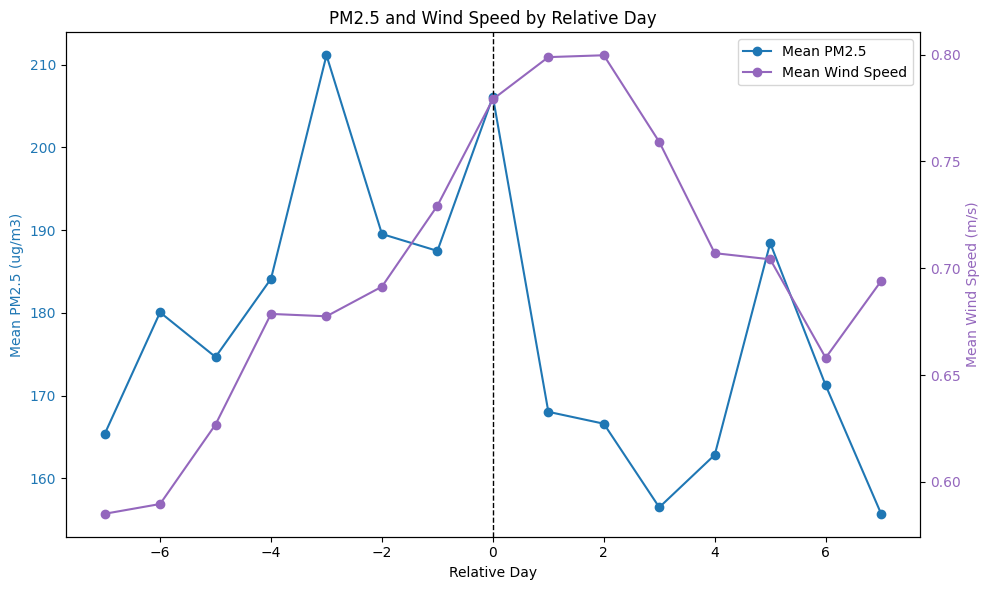

In [2]:
daily_means = event_windows.groupby('relative_day')[
    ['pm25_ugm3', 'air_temp_c', 'rh_pct', 'wind_speed_ms']
].mean()

fig, ax1 = plt.subplots(figsize=(10, 6))

# PM2.5 on the primary (left) y-axis.
line1, = ax1.plot(daily_means.index, daily_means['pm25_ugm3'], color='tab:blue', marker='o', label='Mean PM2.5')
ax1.set_xlabel('Relative Day')
ax1.set_ylabel('Mean PM2.5 (ug/m3)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Wind speed on the secondary (right) y-axis, sharing the same x-axis.
ax2 = ax1.twinx()
line2, = ax2.plot(daily_means.index, daily_means['wind_speed_ms'], color='tab:purple', marker='o', label='Mean Wind Speed')
ax2.set_ylabel('Mean Wind Speed (m/s)', color='tab:purple')
ax2.tick_params(axis='y', labelcolor='tab:purple')

# Mark the event day with a dashed vertical line spanning the full figure.
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)

ax1.set_title('PM2.5 and Wind Speed by Relative Day')
ax1.legend(handles=[line1, line2], loc='upper right')
fig.tight_layout()
plt.show()

**What this does.** Computes the mean of each variable at every relative day,
then plots mean PM2.5 against the left y-axis and mean wind speed against an
independent right y-axis, sharing the same relative-day x-axis and the same
dashed marker at relative day 0.

**Why this matters.** PM2.5 and wind speed are measured in different units and
sit on very different numeric scales, so a single shared axis would flatten one
of the two lines. A dual axis lets both series be read at their own natural
scale on one figure, without implying that one axis is more important than the
other.

**How to read this.** Read each line against its own axis and its own colour.
Note where the two lines move in the same direction and where they diverge, as a
visual description only -- this chart does not establish that one line's
movement caused the other's.

# Section 2 -- PM2.5 + Temperature

The same dual-axis format, with temperature in place of wind speed.

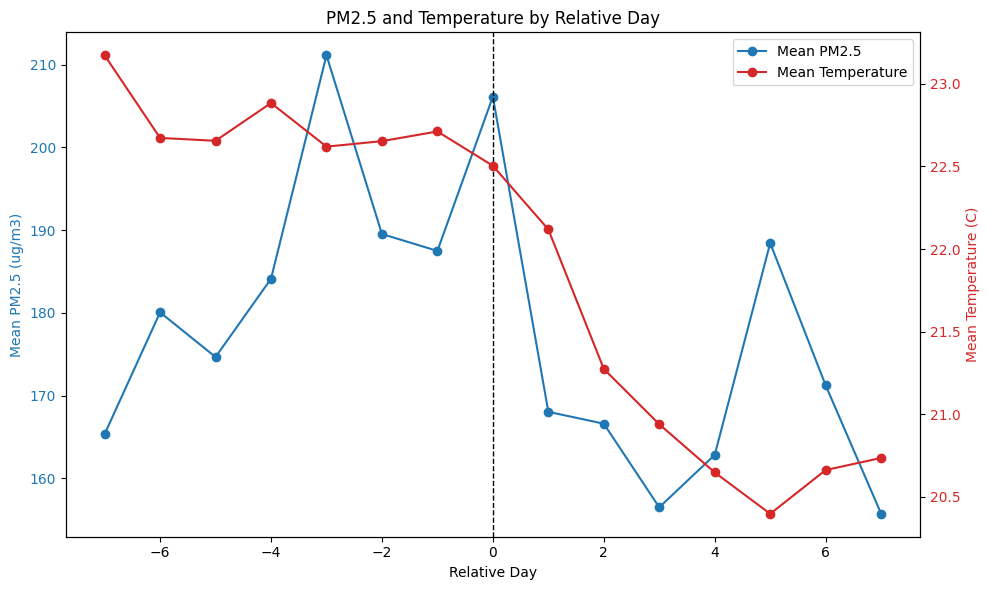

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 6))

line1, = ax1.plot(daily_means.index, daily_means['pm25_ugm3'], color='tab:blue', marker='o', label='Mean PM2.5')
ax1.set_xlabel('Relative Day')
ax1.set_ylabel('Mean PM2.5 (ug/m3)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
line2, = ax2.plot(daily_means.index, daily_means['air_temp_c'], color='tab:red', marker='o', label='Mean Temperature')
ax2.set_ylabel('Mean Temperature (C)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)

ax1.set_title('PM2.5 and Temperature by Relative Day')
ax1.legend(handles=[line1, line2], loc='upper right')
fig.tight_layout()
plt.show()

**What this does.** Repeats the Section 1 construction, replacing wind speed
with temperature on the secondary axis.

**Why this matters.** Temperature governs vertical mixing in the atmosphere, so
seeing its own trajectory next to PM2.5 -- rather than PM2.5 alone -- keeps that
context in view before any pattern in the PM2.5 line is read further.

**How to read this.** Read this chart the same way as Section 1: each line
against its own axis, comparing shape and direction, not magnitude.

# Section 3 -- PM2.5 + Humidity

The same dual-axis format, with humidity in place of temperature.

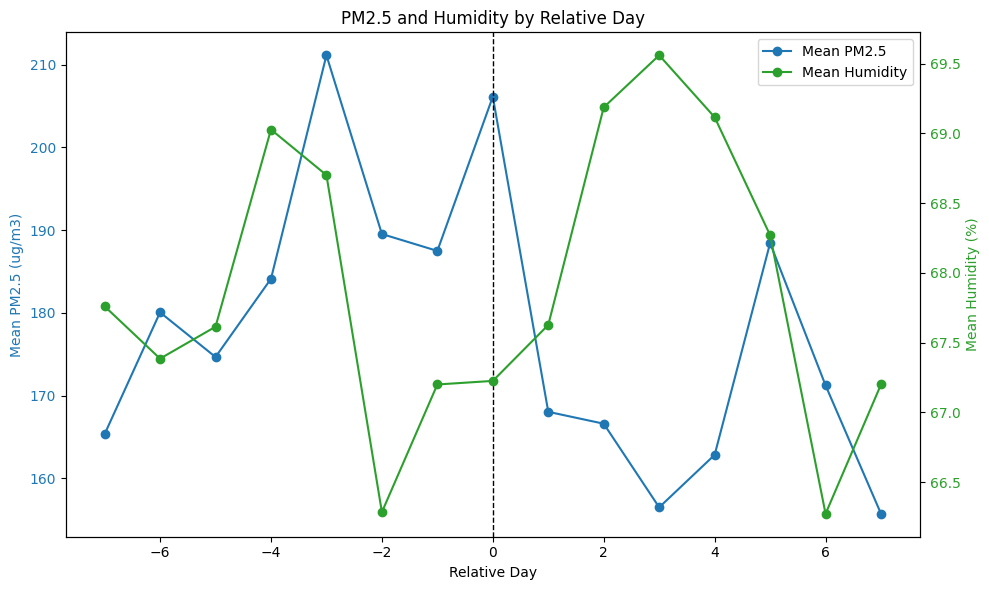

In [4]:
fig, ax1 = plt.subplots(figsize=(10, 6))

line1, = ax1.plot(daily_means.index, daily_means['pm25_ugm3'], color='tab:blue', marker='o', label='Mean PM2.5')
ax1.set_xlabel('Relative Day')
ax1.set_ylabel('Mean PM2.5 (ug/m3)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
line2, = ax2.plot(daily_means.index, daily_means['rh_pct'], color='tab:green', marker='o', label='Mean Humidity')
ax2.set_ylabel('Mean Humidity (%)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)

ax1.set_title('PM2.5 and Humidity by Relative Day')
ax1.legend(handles=[line1, line2], loc='upper right')
fig.tight_layout()
plt.show()

**What this does.** Repeats the same dual-axis construction a third time, with
humidity on the secondary axis.

**Why this matters.** Humidity is linked to particulate formation and settling,
making it the third weather variable worth viewing alongside PM2.5 on its own
terms, completing the set of three dual-axis views.

**How to read this.** Read this chart the same way as Sections 1 and 2, and
consider all three dual-axis charts together as one set before moving to the
summary table and boxplots below.

# Section 4 -- Meteorological Summary

One table reporting the mean, median, standard deviation, and observation count
of temperature, humidity, and wind speed, in each of the Pre, Event, and Post
periods.

In [5]:
period_order = ['Pre', 'Event', 'Post']
variable_specs = [
    ('air_temp_c', 'Temperature (C)'),
    ('rh_pct', 'Humidity (%)'),
    ('wind_speed_ms', 'Wind Speed (m/s)'),
]

# Build one row per variable, with Mean/Median/Std Dev/Count repeated for
# each of the three periods.
summary_rows = []
for column_name, label in variable_specs:
    row_values = []
    for period_name in period_order:
        period_values = event_windows.loc[event_windows['period'] == period_name, column_name]
        row_values.extend([
            round(period_values.mean(), 2),
            round(period_values.median(), 2),
            round(period_values.std(), 2),
            period_values.count(),
        ])
    summary_rows.append(row_values)

column_index = pd.MultiIndex.from_product(
    [period_order, ['Mean', 'Median', 'Std Dev', 'Count']],
    names=['Period', 'Statistic'],
)

meteorological_summary = pd.DataFrame(
    summary_rows,
    index=[label for _, label in variable_specs],
    columns=column_index,
)

meteorological_summary

Period              Pre                       Event                       \
Statistic          Mean Median Std Dev Count   Mean Median Std Dev Count   
Temperature (C)   22.77  24.15    5.39   504  22.50  24.07    5.76    71   
Humidity (%)      67.71  68.31   10.15   504  67.23  68.39   10.02    71   
Wind Speed (m/s)   0.65   0.50    0.65   504   0.78   0.57    0.88    71   

Period             Post                       
Statistic          Mean Median Std Dev Count  
Temperature (C)   20.97  22.54    4.93   504  
Humidity (%)      68.18  67.80   12.14   504  
Wind Speed (m/s)   0.73   0.64    0.54   504

**What this does.** For each of the three weather variables, computes the mean,
median, standard deviation, and count separately within the Pre, Event, and Post
periods, and assembles all three variables into one table with the period and
statistic organised as column headers.

**Why this matters.** This table is the numeric companion to the dual-axis
charts above: instead of a continuous fifteen-day line, it collapses the window
into the same three periods used throughout this project's event-window
analysis, for a compact side-by-side read.

**How to read this.** Compare each statistic across the three periods for one
variable at a time. Note that the Event period is built from a single relative
day (about 71-72 station-events), while Pre and Post are each built from seven
relative days (up to 504 station-events) -- the Event column's statistics rest
on substantially less data than the Pre and Post columns.

# Section 5 -- Variability

Beyond the mean and median reported above, we look at the full spread of each
weather variable within the Pre, Event, and Post periods using box plots.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_44508\3560715756.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(values_by_period, labels=period_order, patch_artist=True)


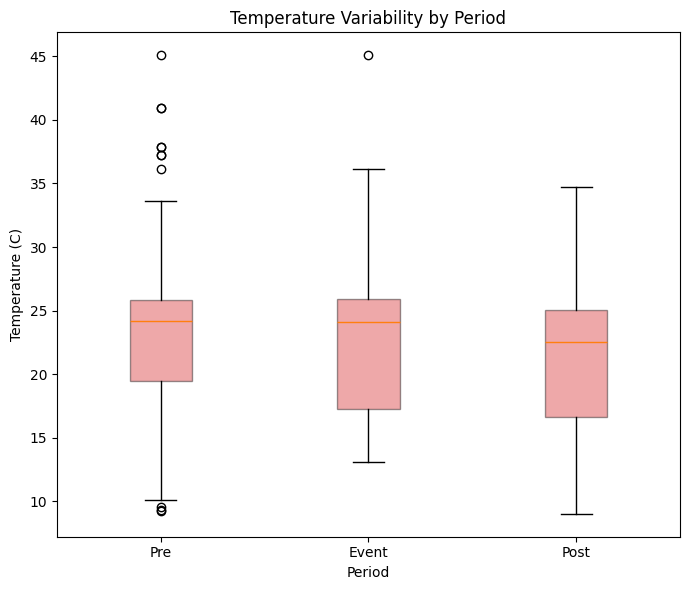

In [6]:
def period_boxplot(column_name, y_label, title, color):
    values_by_period = [
        event_windows.loc[event_windows['period'] == period_name, column_name].dropna()
        for period_name in period_order
    ]

    plt.figure(figsize=(7, 6))
    box = plt.boxplot(values_by_period, labels=period_order, patch_artist=True)
    for patch in box['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.4)

    plt.title(title)
    plt.xlabel('Period')
    plt.ylabel(y_label)
    plt.tight_layout()
    plt.show()

period_boxplot('air_temp_c', 'Temperature (C)', 'Temperature Variability by Period', 'tab:red')

**What this does.** Defines a small helper that splits a column into Pre,
Event, and Post groups and draws one box plot per period on shared axes, then
uses it to draw the temperature box plot.

**Why this matters.** The mean and standard deviation in Section 4 summarize
spread with a single number; a box plot shows the same spread directly --
median, quartiles, whiskers, and outliers -- for each period side by side.

**How to read this.** Compare box height (spread) and median position across
the three periods, and note how many outlier points appear above or below each
box.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_44508\3560715756.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(values_by_period, labels=period_order, patch_artist=True)


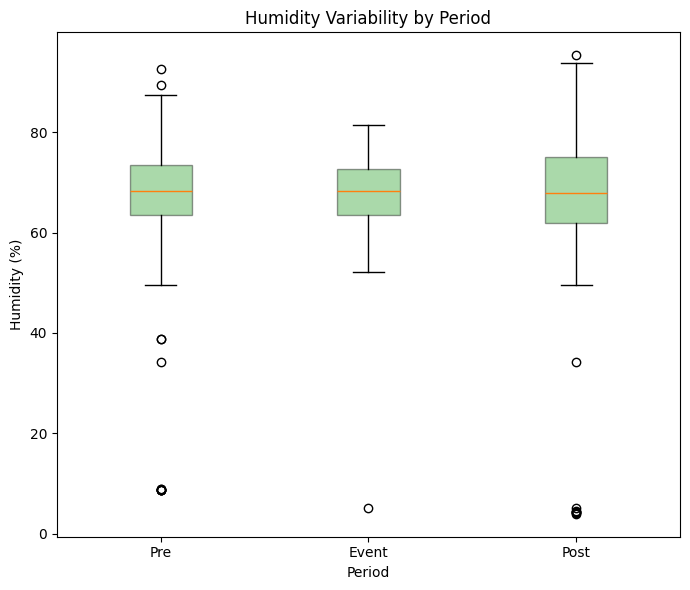

In [7]:
period_boxplot('rh_pct', 'Humidity (%)', 'Humidity Variability by Period', 'tab:green')

**What this does.** Draws the same box plot construction for humidity.

**Why this matters.** Humidity is bounded between 0% and 100%, so its box plot
also shows how close to either boundary the three periods' readings sit.

**How to read this.** Read this box plot the same way as the temperature one,
and compare its shape across periods against the temperature box plot.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_44508\3560715756.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(values_by_period, labels=period_order, patch_artist=True)


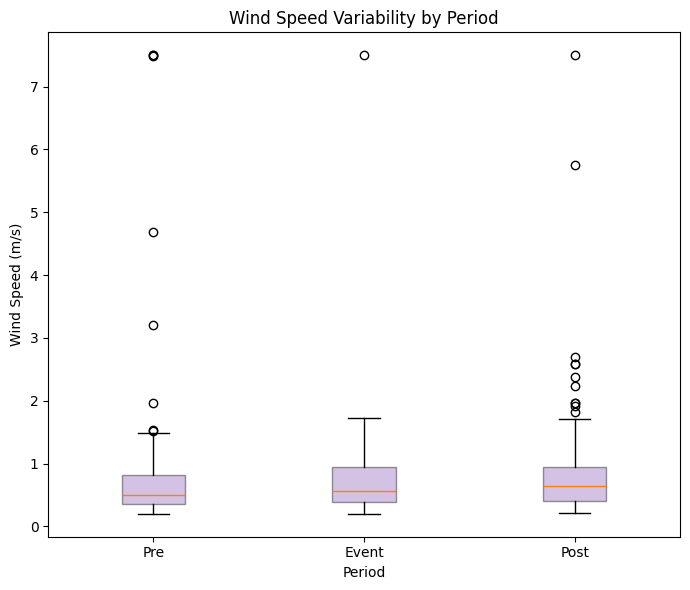

In [8]:
period_boxplot('wind_speed_ms', 'Wind Speed (m/s)', 'Wind Speed Variability by Period', 'tab:purple')

**What this does.** Draws the same box plot construction for wind speed,
completing the set of three.

**Why this matters.** Wind speed cannot be negative, so its box plot is expected
to start at zero; seeing where the bulk of each period's readings sit above that
floor completes the variability picture alongside temperature and humidity.

**How to read this.** Read this box plot the same way as the previous two, then
consider all three box plots together against the Section 4 table before moving
to the methodological notes below.

# Section 6 -- Methodological Notes

**Why weather is treated as contextual information.** Every chart and table in
this notebook places a weather variable next to PM2.5 -- it does not test one
against the other. No correlation coefficient, regression slope, or other
statistical measure of association is computed anywhere here. The purpose is to
let a reader see what conditions were present around each GRAP event, not to
quantify how strongly weather and pollution move together.

**Why meteorological conditions are considered potential confounders.**
`docs/analysis_plan.md` documents temperature, humidity, and wind speed as
confounding variables for this project's event-window design: all three change
for reasons unrelated to GRAP, and all three are independently known to affect
how PM2.5 disperses or accumulates. Because weather and GRAP stage both move
across the same calendar days, any pattern in the PM2.5 profile could plausibly
be shaped by either -- which is precisely why this notebook exists, to make the
weather side of that overlap visible rather than leaving it implicit.

**Why descriptive analysis alone cannot isolate weather's effect.** Showing two
lines on one figure, or two box plots side by side, describes what happened; it
does not decompose how much of any pollution movement is attributable to
weather versus anything else. That decomposition would require a statistical
model relating PM2.5 to weather while holding other factors fixed, of the kind
explicitly ruled out for this notebook and reserved, if pursued at all, for the
"partial weather adjustment" step described as future work in
`docs/analysis_plan.md`. Until then, weather remains a documented factor to keep
in mind, not a quantified one.

# Section 7 -- Findings

The statements below describe only what is directly visible in the figures and
table above. None of them involve a computed correlation or any other measure of
association, and none should be read as evidence that weather explains any
pollution pattern.

**Wind speed rises gradually across the window and is highest around the event
day and the day after it.** The relative-day means in Section 1 rise from about
0.58 m/s at relative day -7 to about 0.78-0.80 m/s around relative days 0 to +2,
before easing back to about 0.66-0.73 m/s by relative day +7. The Section 4
table shows the same pattern collapsed into periods: a Pre-period mean of 0.65
m/s, an Event-day mean of 0.78 m/s, and a Post-period mean of 0.73 m/s.

**Temperature declines gradually across the whole window, without a visible step
at the event day.** The Section 2 chart shows mean temperature falling from
about 23.2 C at relative day -7 to about 20.7 C at relative day +7 in a mostly
steady line. The Section 4 table shows a Pre-period mean of 22.77 C, an
Event-day mean of 22.50 C close to the Pre-period level, and a Post-period mean
of 20.97 C.

**Humidity stays within a comparatively narrow band across the window.** The
Section 3 chart shows mean humidity moving between roughly 66% and 70%
throughout, with no pronounced rise or fall around the event day. The Section 4
table shows Pre, Event, and Post means within about one percentage point of each
other (67.71%, 67.23%, and 68.18%).

**The Event period's statistics rest on visibly less data than the Pre and Post
periods.** The Section 4 table's Count column shows 504 station-events for both
Pre and Post but only 71 for the Event period, since the Event period is a
single relative day rather than seven. This is also visible in the box plots in
Section 5, where the Event box for each variable is built from roughly a
seventh as many points as the Pre and Post boxes.

**Variability is not uniform across periods, and differs by variable.** The
Section 5 box plots and the Section 4 standard-deviation column show the Event
period with the widest spread for temperature (std. dev. 5.76 C, versus 5.39 C
Pre and 4.93 C Post) and for wind speed (std. dev. 0.88 m/s, versus 0.65 m/s Pre
and 0.54 m/s Post), while humidity shows its widest spread in the Post period
(std. dev. 12.14%, versus 10.15% Pre and 10.02% Event).

# Questions for Future Work

1. Does the gradual rise in wind speed seen from relative day -7 through the
   event day also appear in periods with no GRAP event nearby, or is it
   specific to these nine event windows?
2. The Event period consistently has the fewest observations (about 71-72) --
   would pooling the event day across a wider set of verified events (once a
   second GRAP season is available) narrow its standard deviation toward the
   Pre/Post level?
3. Does the steady temperature decline across the window reflect the broader
   seasonal cooling documented in `notebooks/05_time_series_exploration.ipynb`,
   or does it look different when examined event by event?
4. Why is the Event period's variability highest for temperature and wind speed
   but not for humidity -- is that specific to these nine event days, or would
   it hold under a different window width (per
   `09_sensitivity_analysis.ipynb`)?
5. Do the three weather variables behave consistently across stations, or does
   the pooled city-wide profile shown here mask station-level differences?
6. If a partial weather adjustment is eventually built (as noted under Future
   Improvements in `docs/analysis_plan.md`), which of the three variables shown
   here would be expected to matter most, given how much each one moves across
   the window?
7. Would adding wind direction, not just wind speed, change the picture given
   by the Section 1 dual-axis chart?
8. Does the narrow humidity range seen here (roughly 66-70%) hold across all
   nine events individually, or do some events sit in a noticeably different
   humidity band than others?

*End of the Weather Context Analysis notebook.*